In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import (
    spearmanr,
)

from link_prediction.config import (
    RESULTS_DIR,
    SUMMARY_RESULTS_DIR,
)
from link_prediction.statistical_analysis import (
    load_benchmark_fold_metrics,
    write_statistical_csv,
)

In [2]:
benchmark_name = "standard"

figure_directory = (
    RESULTS_DIR
    / "figures"
    / benchmark_name
)

figure_directory.mkdir(
    parents=True,
    exist_ok=True,
)

profile_path = (
    SUMMARY_RESULTS_DIR
    / (
        f"{benchmark_name}_"
        "network_profiles.csv"
    )
)

network_profiles = pd.read_csv(
    profile_path
)

fold_metrics = (
    load_benchmark_fold_metrics(
        benchmark_name=
            benchmark_name,
    )
)

In [3]:
network_method_performance = (
    fold_metrics
    .groupby(
        [
            "benchmark",
            "network_id",
            "method_id",
        ],
        as_index=False,
    )[
        "average_precision"
    ]
    .mean()
)

network_performance = (
    network_method_performance
    .groupby(
        [
            "benchmark",
            "network_id",
        ],
        as_index=False,
    )
    .agg(
        method_count=(
            "method_id",
            "nunique",
        ),
        mean_method_average_precision=(
            "average_precision",
            "mean",
        ),
        maximum_method_average_precision=(
            "average_precision",
            "max",
        ),
    )
)

structural_table = (
    network_profiles
    .merge(
        network_performance,
        on="network_id",
        how="inner",
        validate="one_to_one",
    )
)

if len(structural_table) != 8:
    raise ValueError(
        "Structural analysis requires "
        "eight complete networks."
    )

if not (
    structural_table[
        "method_count"
    ] == 27
).all():
    raise ValueError(
        "Structural analysis requires "
        "27 methods per network."
    )

write_statistical_csv(
    structural_table,
    SUMMARY_RESULTS_DIR
    / (
        f"{benchmark_name}_"
        "structural_performance_table.csv"
    ),
)

structural_table[
    [
        "network",
        "domain",
        "processed_nodes",
        "processed_edges",
        "density",
        "average_degree",
        "average_clustering",
        "transitivity",
        "degree_assortativity",
        "method_count",
        "mean_method_average_precision",
        "maximum_method_average_precision",
    ]
].sort_values(
    [
        "domain",
        "network",
    ]
).reset_index(
    drop=True
)

,network,domain,processed_nodes,processed_edges,density,average_degree,average_clustering,transitivity,degree_assortativity,method_count,mean_method_average_precision,maximum_method_average_precision
0,email-Eu-core,communication,986,16064,0.033080,32.584178,0.407050,0.267392,-0.025743,27,0.925429,0.956437
1,email-univ,communication,1133,5451,0.008500,9.622242,0.220176,0.166250,0.078201,27,0.851746,0.938723
2,power-1138-bus,infrastructure,1138,1458,0.002254,2.562390,0.086615,0.093068,-0.080110,27,0.699422,0.813457
3,power-grid,infrastructure,4941,6594,0.000540,2.669095,0.080104,0.103153,0.003457,27,0.679804,0.770728
4,ca-GrQc,scientific_collaboration,4158,13422,0.001553,6.455988,0.556878,0.628894,0.639186,27,0.951057,0.983031
5,ca-HepTh,scientific_collaboration,8638,24806,0.000665,5.743459,0.481564,0.281129,0.238915,27,0.915493,0.968730
6,ego-Facebook,social,4039,88234,0.010820,43.691013,0.605547,0.519174,0.063577,27,0.981436,0.995854
7,socfb-Middlebury45,social,3069,124607,0.026468,81.203649,0.282180,0.210842,0.078415,27,0.934931,0.955594


In [4]:
structural_properties = {
    "processed_nodes":
        "Processed nodes",
    "density":
        "Density",
    "average_degree":
        "Average degree",
    "average_clustering":
        "Average clustering",
    "transitivity":
        "Transitivity",
    "degree_assortativity":
        "Degree assortativity",
}

performance_columns = {
    "mean_method_average_precision":
        "Mean method AP",
    "maximum_method_average_precision":
        "Maximum method AP",
}

correlation_rows = []

for (
    property_column,
    property_label,
) in structural_properties.items():
    for (
        performance_column,
        performance_label,
    ) in performance_columns.items():
        result = spearmanr(
            structural_table[
                property_column
            ],
            structural_table[
                performance_column
            ],
        )

        correlation_rows.append(
            {
                "structural_property":
                    property_column,
                "structural_property_label":
                    property_label,
                "performance_measure":
                    performance_column,
                "performance_measure_label":
                    performance_label,
                "network_count":
                    len(
                        structural_table
                    ),
                "spearman_correlation":
                    float(
                        result.statistic
                    ),
                "p_value":
                    float(
                        result.pvalue
                    ),
            }
        )

structural_correlations = (
    pd.DataFrame(
        correlation_rows
    )
)

write_statistical_csv(
    structural_correlations,
    SUMMARY_RESULTS_DIR
    / (
        f"{benchmark_name}_"
        "exploratory_structural_correlations.csv"
    ),
)

structural_correlations

,structural_property,structural_property_label,performance_measure,performance_measure_label,network_count,spearman_correlation,p_value
0,processed_nodes,Processed nodes,mean_method_average_precision,Mean method AP,8,0.000000,1.000000
1,processed_nodes,Processed nodes,maximum_method_average_precision,Maximum method AP,8,0.190476,0.651401
2,density,Density,mean_method_average_precision,Mean method AP,8,0.500000,0.207031
3,density,Density,maximum_method_average_precision,Maximum method AP,8,0.261905,0.530923
4,average_degree,Average degree,mean_method_average_precision,Mean method AP,8,0.738095,0.036553
5,average_degree,Average degree,maximum_method_average_precision,Maximum method AP,8,0.500000,0.207031
6,average_clustering,Average clustering,mean_method_average_precision,Mean method AP,8,0.904762,0.002008
7,average_clustering,Average clustering,maximum_method_average_precision,Maximum method AP,8,1.000000,0.000000
8,transitivity,Transitivity,mean_method_average_precision,Mean method AP,8,0.857143,0.006530
9,transitivity,Transitivity,maximum_method_average_precision,Maximum method AP,8,0.952381,0.000260


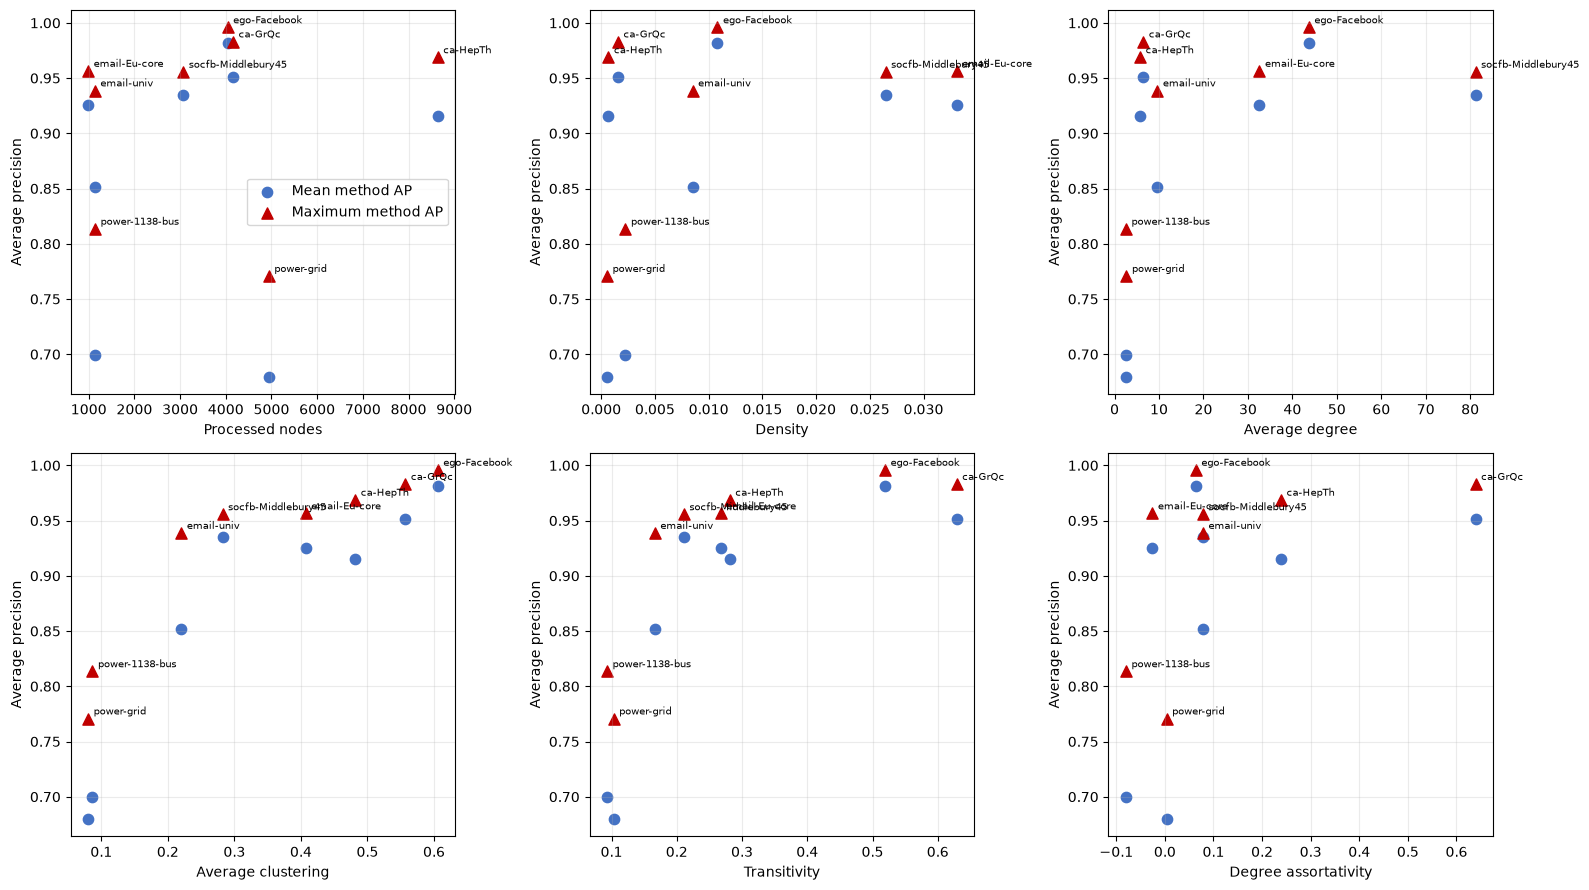

In [5]:
figure, axes = plt.subplots(
    2,
    3,
    figsize=(
        16,
        9,
    ),
)

for (
    property_column,
    property_label,
), axis in zip(
    structural_properties.items(),
    axes.ravel(),
    strict=True,
):
    axis.scatter(
        structural_table[
            property_column
        ],
        structural_table[
            "mean_method_average_precision"
        ],
        marker="o",
        s=55,
        color="#4472C4",
        label="Mean method AP",
    )

    axis.scatter(
        structural_table[
            property_column
        ],
        structural_table[
            "maximum_method_average_precision"
        ],
        marker="^",
        s=65,
        color="#C00000",
        label="Maximum method AP",
    )

    for row in (
        structural_table.itertuples()
    ):
        axis.annotate(
            row.network,
            (
                getattr(
                    row,
                    property_column,
                ),
                row.maximum_method_average_precision,
            ),
            xytext=(
                4,
                3,
            ),
            textcoords="offset points",
            fontsize=7,
        )

    axis.set_xlabel(
        property_label
    )

    axis.set_ylabel(
        "Average precision"
    )

    axis.grid(
        alpha=0.25,
    )

axes[
    0,
    0,
].legend()

figure.tight_layout()

figure.savefig(
    figure_directory
    / "structural_performance_scatterplots.png",
    dpi=300,
    bbox_inches="tight",
)

figure.savefig(
    figure_directory
    / "structural_performance_scatterplots.pdf",
    bbox_inches="tight",
)

plt.show()

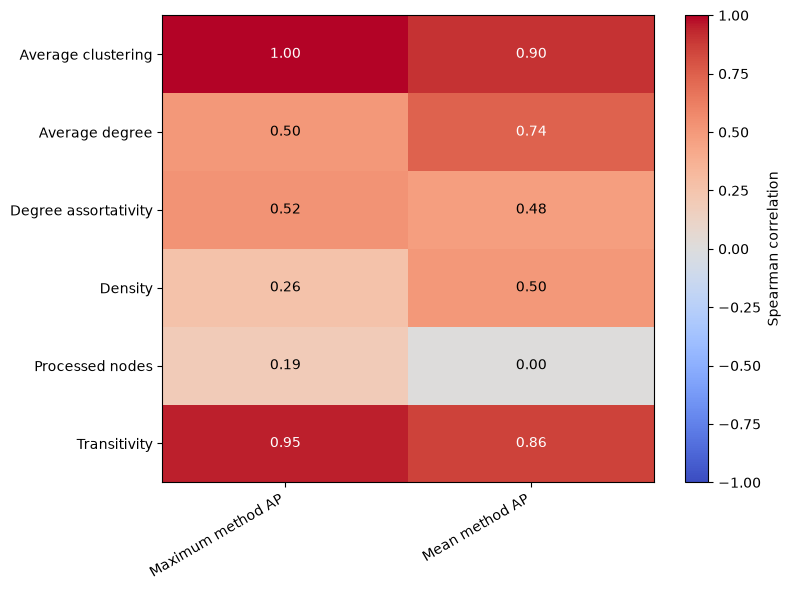

In [6]:
correlation_matrix = (
    structural_correlations
    .pivot(
        index="structural_property_label",
        columns="performance_measure_label",
        values="spearman_correlation",
    )
)

figure, axis = plt.subplots(
    figsize=(
        8,
        6,
    )
)

image = axis.imshow(
    correlation_matrix.to_numpy(),
    aspect="auto",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
)

axis.set_xticks(
    range(
        len(
            correlation_matrix.columns
        )
    )
)

axis.set_xticklabels(
    correlation_matrix.columns,
    rotation=30,
    ha="right",
)

axis.set_yticks(
    range(
        len(
            correlation_matrix.index
        )
    )
)

axis.set_yticklabels(
    correlation_matrix.index,
)

for row_index in range(
    len(
        correlation_matrix.index
    )
):
    for column_index in range(
        len(
            correlation_matrix.columns
        )
    ):
        value = correlation_matrix.iloc[
            row_index,
            column_index,
        ]

        axis.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=(
                "white"
                if abs(value) >= 0.6
                else "black"
            ),
        )

colorbar = figure.colorbar(
    image,
    ax=axis,
)

colorbar.set_label(
    "Spearman correlation"
)

figure.tight_layout()

figure.savefig(
    figure_directory
    / "exploratory_structural_correlations.png",
    dpi=300,
    bbox_inches="tight",
)

figure.savefig(
    figure_directory
    / "exploratory_structural_correlations.pdf",
    bbox_inches="tight",
)

plt.show()